%pip install -U -q numpy pandas wfdb matplotlib notebook

In [ ]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

import funkcje
from processor import Signal, ICP_ABP_Processor

## Sekcja wczytwania


Rekord: charis1
Długość: 12239851 próbek (68.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


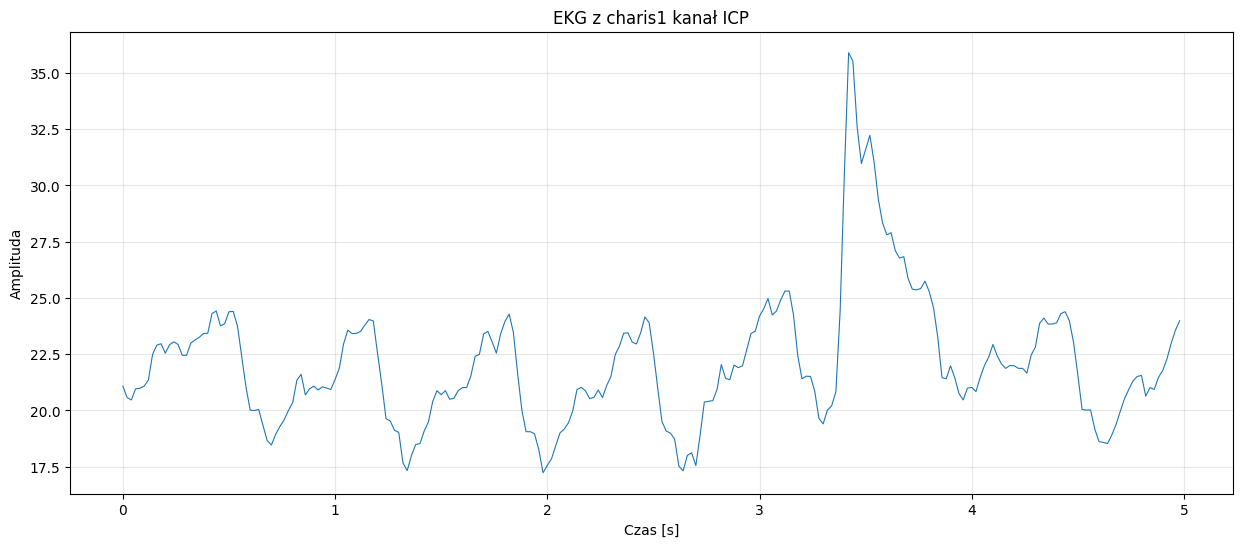

In [ ]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis1'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

# TERAZ TWÓJ KOD BEZ ZMIAN
local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # ['ABP', 'ECG', 'ICP']


# def packet_averaging(signal, scale=250):
    # packet_means = []  # Store averaged packets
    # for start_idx in range(0, len(signal), scale):
    #     end_idx = min(start_idx + scale, len(signal))  # Handle end of signal
    #     packet = signal[start_idx:end_idx]
    #     avg = np.mean(packet)
    #     packet_means.append(avg)
    
    # return np.array(packet_means)  # Return averaged signal

# def packet_windowing_and_regression(ABP, ICP, duration=60):
    # results = []  # Lista wyników regresji dla okien
    # min_len = min(len(ABP), len(ICP))
    
    # for start_idx in range(0, min_len, duration):  # Tylko start_idx!
    #     end_idx = min(start_idx + duration, min_len)
    #     win_ABP = ABP[start_idx:end_idx]
    #     win_ICP = ICP[start_idx:end_idx]
        
    #     # Regresja liniowa ICP ~ ABP w oknie
    #     if len(win_ABP) > 1:  # Min. 2 punkty do regresji
    #         X = win_ABP.reshape(-1, 1)
    #         model = LinearRegression().fit(X, win_ICP)
    #         r2 = model.score(X, win_ICP)
    #         results.append({
    #             'window': start_idx//duration,
    #             'beta0': model.intercept_,
    #             'beta1': model.coef_[0],
    #             'R2': r2
    #         })
    
    # return np.array(results)
        
channel_ABP = signals[0]
channel_ICP = signals[2]

# Inicjalizacja
processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=50)
processor.process_all()

# Pobieranie okien do dalszej analizy (np. korelacji PRx)
okna_icp, okna_abp = processor.get_windowed_data(x_seconds_avg=10, window_size=30)


averaged_signal_ABP = packet_averaging(signal=channel_ABP, scale=250)
averaged_signal_ICP = packet_averaging(signal=channel_ICP, scale=250)

print(packet_windowing_and_regression(ABP=averaged_signal_ABP, ICP=averaged_signal_ICP, duration=60))

# Wizualizacja pierwszych 60s
plt.figure(figsize=(15, 6))
plt.plot(time[:int(5*fs)], signal[:int(5*fs)], linewidth=0.8)
plt.xlabel('Czas [s]')
plt.ylabel('Amplituda')
plt.title(f'EKG z {record_name} kanał {record.sig_name[channel]}')
plt.grid(True, alpha=0.3)
plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')
